# Project 1 — Bandit Algorithms on the Moon Game

Jack Farrell

CS5180 Reinforcement Learning

22Jun26

Project 1

**AI Usage:** In addition to general debugging, I used ChatGPT to help explain some new coding concepts to me such as one-hot masks and to help understand how the BanditAgent class was setup so that I could read and interpret the ε-greedy algorithm and later apply to the UCB and greedy-bandit algorithms.

**Goal.** Implement three exploration strategies — ε-greedy, UCB, and gradient bandit — and compare them on a stochastic version of the Moon game.

The Moon game is a one-step MDP — equivalently, a multi-armed bandit. We'll treat each bandit algorithm as a special case of **Generalized Policy Iteration**:

- **Evaluation:** keep an estimate of action values $Q(a)$ as data arrives.
- **Improvement:** select the next action based on $Q$ (and possibly some exploration term).

ε-greedy, UCB, and gradient bandit differ only in *how the improvement step is done*. The evaluation step is essentially the same incremental average.

**Reference.** Sutton & Barto 2nd ed., Chapter 2 (Multi-armed Bandits) and §4.6 (Generalized Policy Iteration).

## Part 1 — Setup

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

plt.rcParams['figure.figsize'] = (10, 4.5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### The vocabulary

Same fixed list of nouns from the Lesson 1 demo. The action space $\mathcal{A}$ is exactly this list.

In [124]:
ITEMS = [
    "pencil", "pen", "paper", "phone", "pillow", "plate", "puzzle",
    "apple", "ant", "axe", "arrow",
    "book", "ball", "boot", "brick",
    "cup", "card", "candle", "chair", "comb",
    "drum", "dish", "doll",
    "egg", "envelope",
    "fork", "flag", "fan",
    "glove", "guitar",
    "hat", "hammer", "horn",
    "ice", "ink",
    "jar", "jacket",
    "key", "kite",
    "lamp", "lemon", "lock",
    "map", "match", "mirror", "moon",
    "nail", "net", "note",
    "orange", "owl",
    "rope", "ring", "rock",
    "spoon", "shoe", "stamp",
    "torch", "tape",
    "umbrella",
    "watch", "whistle",
]
N_ACTIONS = len(ITEMS)
print(f"|A| = {N_ACTIONS}")

|A| = 62


### The environment

A **stochastic** version of the Moon game. The hidden rule is still *"item starts with `p`"*, but reward is noisy:

- If the item satisfies the rule: reward $= +1$ with probability $0.8$, else $-1$.
- If the item violates the rule: reward $= -1$ with probability $0.8$, else $+1$.

Expected reward of an optimal (p-word) action: $\mathbb{E}[r \mid \text{good}] = 0.8(+1) + 0.2(-1) = +0.6$.

Expected reward of a suboptimal action: $-0.6$.

This noise is what makes exploration genuinely necessary.

In [125]:
class MoonBandit:
    def __init__(self, target_letter='p', noise=0.2):
        self.target_letter = target_letter
        self.noise = noise

    def step(self, item):
        good = item.startswith(self.target_letter)
        # Flip the outcome with probability `noise`
        if np.random.random() < self.noise:
            good = not good
        return +1 if good else -1

    def is_optimal(self, item):
        return item.startswith(self.target_letter)

    @property
    def optimal_expected_reward(self):
        return 1.0 - 2.0 * self.noise   # = 0.6 for noise=0.2

env = MoonBandit()
print(f"Optimal expected reward per step: {env.optimal_expected_reward}")

Optimal expected reward per step: 0.6


## Part 2 — The GPI Framing

Every bandit algorithm in this lab follows the same two-step loop:

```
loop:
    a  ← improvement(Q)        # choose action based on current value estimates
    r  ← env.step(a)            # observe reward
    Q  ← evaluation(Q, a, r)    # update value estimates
```

This is Generalized Policy Iteration in its degenerate (one-state) form. Each algorithm we implement is a different choice of `improvement`. The evaluation step is the same incremental mean update:

$$Q_{n+1}(a) = Q_n(a) + \frac{1}{N(a)} \bigl( R - Q_n(a) \bigr)$$

### The base class

All three agents will share this scaffold.

In [126]:
class BanditAgent:
    """Abstract base. Subclasses must implement act() and may override update()."""
    def __init__(self, items):
        self.items = items
        self.n = len(items)
        self.Q = np.zeros(self.n)          # value estimates, initalized to 0
        self.N = np.zeros(self.n, dtype=int)  # visit counts, initialized to 0
        self.t = 0                          # total steps, initialized to 0

    def _idx(self, item):
        return self.items.index(item)

    def act(self):
        raise NotImplementedError

    def update(self, item, reward):
        """Incremental mean update. Used by epsilon-greedy and UCB."""
        a = self._idx(item)
        self.N[a] += 1
        self.t += 1
        self.Q[a] += (reward - self.Q[a]) / self.N[a]

## Part 3 — ε-greedy (This has been done for you, walk through it to make sure you understand it.)

The simplest exploration strategy:

- With probability $\varepsilon$: explore — pick uniformly at random.
- With probability $1 - \varepsilon$: exploit — pick $\arg\max_a Q(a)$.

The full implementation is below. Read it carefully — the next two algorithms follow the same pattern.

In [127]:
class EpsilonGreedyAgent(BanditAgent):
    def __init__(self, items, epsilon=0.1):
        super().__init__(items)
        self.epsilon = epsilon

    def act(self):
        if np.random.random() < self.epsilon:
            # Explore
            return self.items[np.random.randint(self.n)]
        else:
            # Exploit: tie-break randomly among argmax actions
            best = np.flatnonzero(self.Q == self.Q.max())
            return self.items[np.random.choice(best)]

    # update() is inherited from BanditAgent

### Tests for ε-greedy

Run this cell. All three checks should print ✓.

In [128]:
# Test 1: with epsilon=0, agent should exploit after seeing a positive reward
np.random.seed(0)
agent = EpsilonGreedyAgent(['a', 'b', 'c'], epsilon=0.0)
agent.update('a', +1)
picks = [agent.act() for _ in range(20)]
assert all(p == 'a' for p in picks), f"epsilon=0 should always exploit; got {picks}"
print("✓ epsilon=0 always exploits the best-known action")

# Test 2: with epsilon=1, action selection should be roughly uniform
np.random.seed(0)
agent = EpsilonGreedyAgent(['a', 'b', 'c'], epsilon=1.0)
counts = defaultdict(int)
for _ in range(3000):
    counts[agent.act()] += 1
for k, v in counts.items():
    assert 850 < v < 1150, f"epsilon=1 should be uniform; got {dict(counts)}"
print("✓ epsilon=1 selects uniformly at random")

# Test 3: Q-values track the running average correctly
agent = EpsilonGreedyAgent(['a', 'b'], epsilon=0.0)
for r in [1.0, -1.0, 1.0]:
    agent.update('a', r)
expected = (1 - 1 + 1) / 3
assert abs(agent.Q[0] - expected) < 1e-9, f"Q tracking failed; expected {expected}, got {agent.Q[0]}"
print("✓ incremental mean update is correct")

✓ epsilon=0 always exploits the best-known action
✓ epsilon=1 selects uniformly at random
✓ incremental mean update is correct


## Part 4 — UCB (your turn)

Upper Confidence Bound replaces "$\varepsilon$ chance of random" with a deterministic exploration bonus:

$$a_t = \arg\max_a \Bigl[ Q_t(a) + c \sqrt{\frac{\ln t}{N_t(a)}} \Bigr]$$

The bonus is large when $N_t(a)$ is small (we haven't tried this action much) and shrinks over time. Untried actions are treated as having $+\infty$ value, so UCB tries every action at least once.

**Your task:** implement `act()`. The `update()` method is inherited unchanged.

**Hints:**
- Force exploration first: if any `self.N[a] == 0`, return that action.
- Otherwise compute UCB bonuses and return $\arg\max$.
- Use `np.log(self.t)` for $\ln t$. (After the forced-exploration phase, $t \geq N_{\text{actions}}$, so the log is always defined.)
- Break ties randomly using the same `np.flatnonzero` trick as ε-greedy.

In [129]:
class UCBAgent(BanditAgent):
    def __init__(self, items, c=2.0):
        super().__init__(items)
        self.c = c

    def act(self):
        # TODO 1: if any action has never been tried (self.N[a] == 0),
        #         return that action to force initial exploration.
        #         (Hint: np.argmin or np.flatnonzero on self.N)
        untried = np.flatnonzero(self.N == 0)
        #print(untried)
        
        for a in untried:
            return self.items[a]

        # TODO 2: compute UCB for every action:
        #         ucb[a] = self.Q[a] + self.c * sqrt( ln(self.t) / self.N[a] )
        ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

        # TODO 3: return argmax, breaking ties randomly.
        best = np.flatnonzero(ucb == ucb.max())     # creates array of true and false for which values are equal to the maximum of ucb
        return self.items[np.random.choice(best)]   # where any two values are both true (for having the same value), one is randomly chosen.

### Tests for UCB

These should all print "Correct" once your implementation is correct.

In [130]:
# Test 1: UCB tries every action at least once in the first |A| steps
np.random.seed(0)
agent = UCBAgent(['a', 'b', 'c'], c=2.0)
chosen = []
for _ in range(3):
    a = agent.act()
    chosen.append(a)
    agent.update(a, 0.0)
assert set(chosen) == {'a', 'b', 'c'}, f"UCB should explore all actions first; got {chosen}"
print("Correct UCB forces every action to be tried at least once")

# Test 2: with c=0, UCB reduces to greedy after the forced-exploration phase
np.random.seed(0)
agent = UCBAgent(['a', 'b'], c=0.0)
# Manually drive forced exploration
for item, r in [('a', +1), ('b', -1)]:
    agent.update(item, r)
# Q['a'] = 1, Q['b'] = -1, so c=0 UCB should always pick 'a'
picks = [agent.act() for _ in range(10)]
assert all(p == 'a' for p in picks), f"c=0 UCB should always pick the best Q; got {picks}"
print("Correct: UCB with c=0 reduces to greedy")

# Test 3: the exploration bonus shrinks with more visits
np.random.seed(0)
agent = UCBAgent(['a', 'b'], c=2.0)
# Try 'a' many times, 'b' just once. Reward is the same (0).
agent.update('a', 0.0); agent.update('b', 0.0)
for _ in range(50):
    agent.update('a', 0.0)
# Now Q is equal but N differs hugely. UCB should pick 'b' to reduce its uncertainty.
picks = [agent.act() for _ in range(10)]
assert picks.count('b') > picks.count('a'), \
    f"UCB should favor under-explored 'b'; got {picks.count('b')} b's vs {picks.count('a')} a's"
print("Correct: UCB favors under-explored actions")

Correct UCB forces every action to be tried at least once
Correct: UCB with c=0 reduces to greedy
Correct: UCB favors under-explored actions


## Part 5 — Gradient Bandit (your turn)

Instead of tracking action *values*, the gradient bandit tracks action *preferences* $H(a)$, and picks actions according to a softmax:

$$\pi_t(a) = \frac{\exp H_t(a)}{\sum_{b} \exp H_t(b)}$$

After each step, preferences are updated by stochastic gradient ascent on expected reward:

- For the chosen action $A_t$:
  $\quad H_{t+1}(A_t) = H_t(A_t) + \alpha (R_t - \bar{R}_t)(1 - \pi_t(A_t))$
- For every other action $a \neq A_t$:
  $\quad H_{t+1}(a) = H_t(a) - \alpha (R_t - \bar{R}_t)\pi_t(a)$

Here $\bar{R}_t$ is a *baseline* — the running mean of all rewards seen so far. Subtracting it reduces variance.

**Your task:** implement `act()` and `update()`. Note: this agent does **not** use the inherited `update()` because there's no $Q$ to track.

**Hints:**
- For numerical stability, compute softmax as `exp(H - max(H)) / sum(...)`.
- Use `np.random.choice(self.n, p=probs)` to sample from the softmax.
- The baseline update is the same incremental mean we used for $Q$: $\bar{R}_{t+1} = \bar{R}_t + \frac{1}{t}(R_t - \bar{R}_t)$.

In [131]:
class GradientBanditAgent(BanditAgent):
    def __init__(self, items, alpha=0.1):
        super().__init__(items)
        self.alpha = alpha
        self.H = np.zeros(self.n)    # preferences
        self.baseline = 0.0           # running mean of rewards

    def _probs(self):
        """Softmax over preferences, with numerical stabilization."""
        z = self.H - self.H.max()
        e = np.exp(z)
        return e / e.sum()

    def act(self):
        # TODO 1: compute the softmax probabilities self._probs()
        softmax_probs = self._probs()

        # TODO 2: sample an index according to those probabilities
        #         (Hint: np.random.choice(self.n, p=probs))
        index = np.random.choice(self.n, p = softmax_probs)
        
        # TODO 3: return self.items[idx]
        return self.items[index]

    def update(self, item, reward):
        # TODO 1: increment self.t
        self.t += 1

        # TODO 2: update the baseline incrementally:
        #         self.baseline += (reward - self.baseline) / self.t
        self.baseline += (reward - self.baseline) / self.t

        # TODO 3: compute softmax probs
        softmax_probs = self._probs()

        # TODO 4: for the chosen action index a,
        #             H[a] += alpha * (reward - baseline) * (1 - probs[a])
        #         for every other index b,
        #             H[b] -= alpha * (reward - baseline) * probs[b]
        #         (Hint: do this as a vectorized update using a one-hot mask.)
        one_hot = np.zeros(self.n)
        a = self._idx(item)  # sources the action take fromt the index
        one_hot[a] = 1      # creates one-hot array where only the chosen action is 1, for all actions, b, that are not chosen, one-hot = 0

        self.H += self.alpha * (reward - self.baseline) * (one_hot - softmax_probs)

        pass

### Tests for gradient bandit

In [132]:
# Test 1: a single positive-advantage update raises chosen H and lowers others.
# We first establish a baseline of 0 with mixed rewards, then test the third update.
np.random.seed(0)
agent = GradientBanditAgent(['a', 'b'], alpha=0.5)
agent.update('a', +1.0)   # baseline becomes 1.0; no H change since (r-b)=0
agent.update('b', -1.0)   # baseline becomes 0.0; H differentiates
H_before = agent.H.copy()
agent.update('a', +1.0)   # advantage > 0, so H[a] should rise, H[b] should fall
assert agent.H[0] > H_before[0], f"H[a] should rise; was {H_before[0]:.3f}, now {agent.H[0]:.3f}"
assert agent.H[1] < H_before[1], f"H[b] should fall; was {H_before[1]:.3f}, now {agent.H[1]:.3f}"
print("Correct: Chosen and unchosen preferences move in opposite directions")

# Test 2: under sustained reward asymmetry, the softmax dominates toward the rewarded action.
# Note: with a baseline that tracks the mean reward, constant-reward updates produce no
# gradient. We need varied rewards across actions to see preferences diverge.
np.random.seed(0)
agent = GradientBanditAgent(['a', 'b', 'c'], alpha=0.1)
for _ in range(200):
    agent.update('a', +1.0)
    agent.update('b', -1.0)
probs = agent._probs()
a_idx, b_idx = agent.items.index('a'), agent.items.index('b')
assert probs[a_idx] > probs[b_idx], f"P(a) should exceed P(b); got {probs}"
print(f"Correct: Preferences shift toward higher-reward action (P(a)={probs[a_idx]:.3f}, P(b)={probs[b_idx]:.3f})")

# Test 3: baseline tracks the running mean of rewards
np.random.seed(0)
agent = GradientBanditAgent(['a', 'b'], alpha=0.1)
for r in [+1.0, -1.0, +1.0, -1.0, +1.0]:
    agent.update('a', r)
assert abs(agent.baseline - 0.2) < 1e-9, f"Baseline should be mean = 0.2; got {agent.baseline}"
print("Correct: Baseline tracks the running mean of rewards")

Correct: Chosen and unchosen preferences move in opposite directions
Correct: Preferences shift toward higher-reward action (P(a)=1.000, P(b)=0.000)
Correct: Baseline tracks the running mean of rewards


## Part 6 — Compare the Three Algorithms

We'll run each agent for 2000 turns, averaged over 30 random seeds, and plot two diagnostics:

1. **Cumulative reward.** Higher is better.
2. **Fraction of optimal actions.** Of all actions taken so far, what fraction satisfied the hidden rule?

Single-run plots are noisy and can be misleading — averaging over seeds is standard practice.

In [133]:
def run_seeds(AgentClass, agent_kwargs, n_turns=2000, n_seeds=30):
    """Run an agent for n_seeds independent trials. Returns (rewards, optimal) arrays
    of shape (n_seeds, n_turns)."""
    all_rewards = np.zeros((n_seeds, n_turns))
    all_optimal = np.zeros((n_seeds, n_turns))
    for seed in range(n_seeds):
        np.random.seed(seed)
        env = MoonBandit()
        agent = AgentClass(ITEMS, **agent_kwargs)
        for t in range(n_turns):
            item = agent.act()
            r = env.step(item)
            agent.update(item, r)
            all_rewards[seed, t] = r
            all_optimal[seed, t] = 1 if env.is_optimal(item) else 0
    return all_rewards, all_optimal

# Run all three. (~30 seconds total)
print("Running epsilon-greedy...")
eg_r,  eg_o  = run_seeds(EpsilonGreedyAgent, {'epsilon': 0.1})
print("Running UCB...")
ucb_r, ucb_o = run_seeds(UCBAgent,           {'c': 2.0})
print("Running gradient bandit...")
gb_r,  gb_o  = run_seeds(GradientBanditAgent,{'alpha': 0.1})
print("Done.")

# Added code for Reflection question 3 alternate hyperparameter
print("\nRunning epsilon-greedy alternates...")
eg_r_alt1, eg_o_alt1 = run_seeds(EpsilonGreedyAgent,   {'epsilon': 0.01})
eg_r_alt2, eg_o_alt2 = run_seeds(EpsilonGreedyAgent,   {'epsilon': 0.5})
print("Done")


Running epsilon-greedy...
Running UCB...
Running gradient bandit...
Done.

Running epsilon-greedy alternates...
Done


### Plot 1 — cumulative reward (mean ± std band)

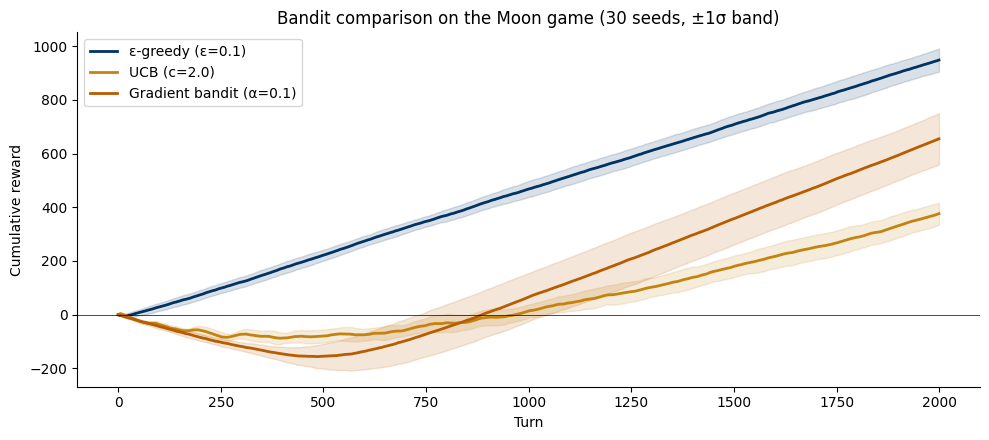

In [134]:
def plot_band(ax, data, label, color):
    cum = np.cumsum(data, axis=1)
    mean = cum.mean(axis=0)
    std  = cum.std(axis=0)
    x = np.arange(data.shape[1])
    ax.plot(x, mean, label=label, color=color, lw=2)
    ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

fig, ax = plt.subplots(figsize=(10, 4.5))
plot_band(ax, eg_r,  'ε-greedy (ε=0.1)',     '#003262')
plot_band(ax, ucb_r, 'UCB (c=2.0)',           '#C4820E')
plot_band(ax, gb_r,  'Gradient bandit (α=0.1)','#B85C00')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Turn')
ax.set_ylabel('Cumulative reward')
ax.set_title('Bandit comparison on the Moon game (30 seeds, ±1σ band)')
ax.legend()
plt.tight_layout()
plt.show()


### Plot 2 — fraction of optimal actions taken

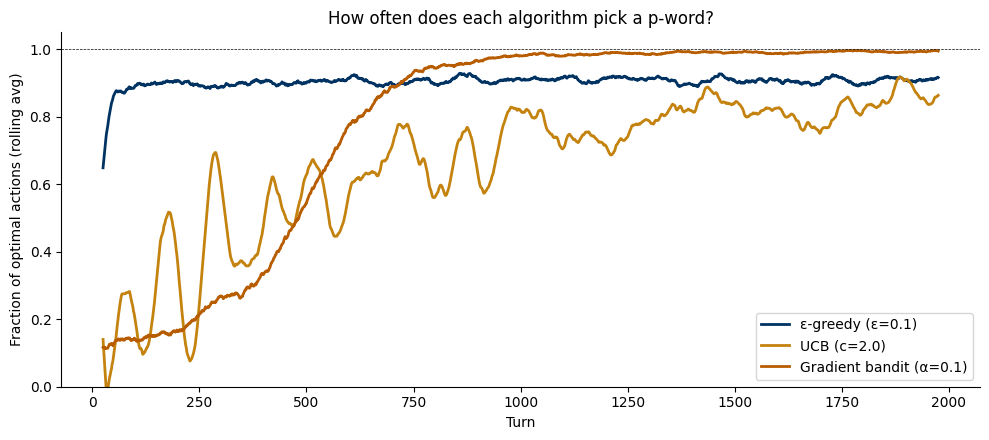

In [135]:
fig, ax = plt.subplots(figsize=(10, 4.5))

def plot_optimal(ax, data, label, color):
    frac = data.mean(axis=0)  # mean across seeds at each time step
    # Smooth with a 50-step rolling window for readability
    window = 50
    smooth = np.convolve(frac, np.ones(window)/window, mode='valid')
    x = np.arange(len(smooth)) + window // 2
    ax.plot(x, smooth, label=label, color=color, lw=2)

plot_optimal(ax, eg_o,  'ε-greedy (ε=0.1)',     '#003262')
plot_optimal(ax, ucb_o, 'UCB (c=2.0)',           '#C4820E')
plot_optimal(ax, gb_o,  'Gradient bandit (α=0.1)','#B85C00')
ax.axhline(1.0, color='black', lw=0.5, linestyle='--')
ax.set_xlabel('Turn')
ax.set_ylabel('Fraction of optimal actions (rolling avg)')
ax.set_title('How often does each algorithm pick a p-word?')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## Plot 3+4 Alternate Hyperparameters for Reflection 3

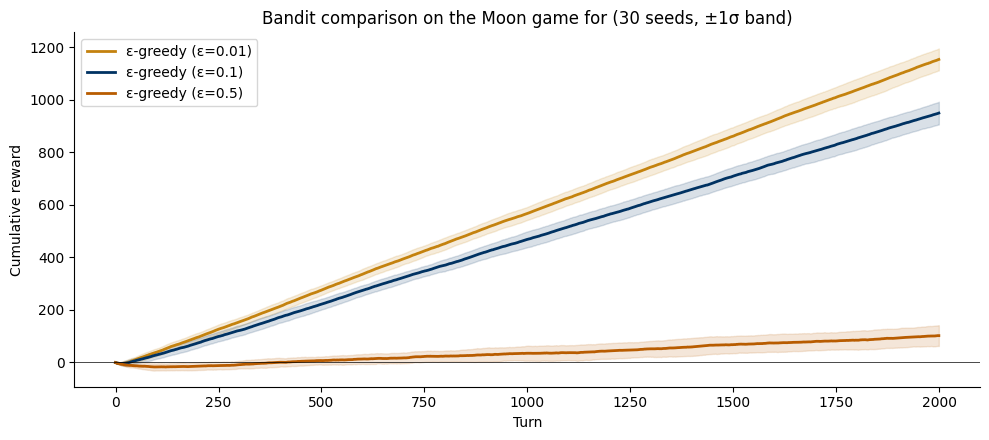

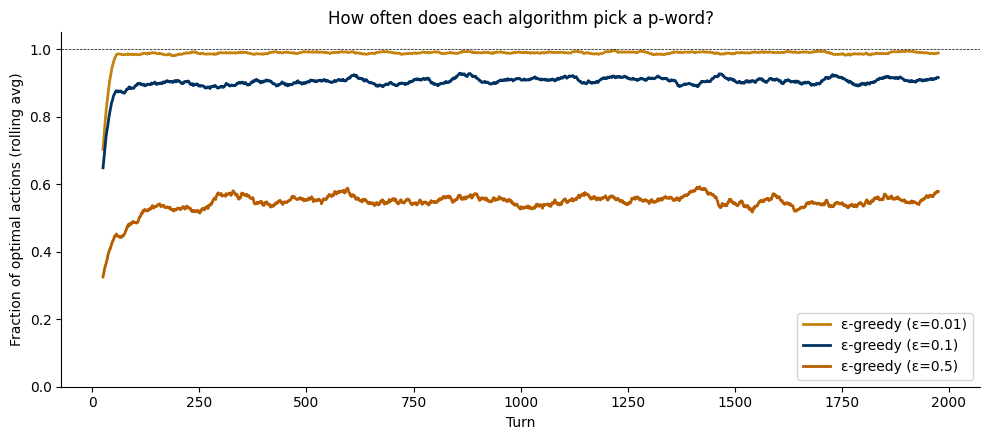

In [136]:
# Plot cumulative reward (mean ± std band)
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_band(ax, eg_r_alt1,  'ε-greedy (ε=0.01)',    '#C4820E')
plot_band(ax, eg_r,       'ε-greedy (ε=0.1)',     '#003262')
plot_band(ax, eg_r_alt2,  'ε-greedy (ε=0.5)',     '#B85C00')
ax.axhline(0, color='black', lw=0.5)
ax.set_xlabel('Turn')
ax.set_ylabel('Cumulative reward')
ax.set_title('Bandit comparison on the Moon game for (30 seeds, ±1σ band)')
ax.legend()
plt.tight_layout()
plt.show()


# Plot fraction of optimal actions taken
fig, ax = plt.subplots(figsize=(10, 4.5))
plot_optimal(ax, eg_o_alt1,  'ε-greedy (ε=0.01)',    '#C4820E')
plot_optimal(ax, eg_o,       'ε-greedy (ε=0.1)',     '#003262')
plot_optimal(ax, eg_o_alt2,  'ε-greedy (ε=0.5)',     '#B85C00')
ax.axhline(1.0, color='black', lw=0.5, linestyle='--')
ax.set_xlabel('Turn')
ax.set_ylabel('Fraction of optimal actions (rolling avg)')
ax.set_title('How often does each algorithm pick a p-word?')
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## Part 7 — Reflection Questions

Write short answers (a few sentences each) in the cells below, or discuss with your neighbor.

1. **Identify the GPI steps in each algorithm.** For ε-greedy, UCB, and gradient bandit, state which line of code is the *evaluation* step and which line is the *improvement* step. Are they the same across the three algorithms? Where do they differ?

    - **ε-greedy**

        - Evalution: happens in the BanditAgent's update function
            - self.Q[a] += (reward - self.Q[a]) / self.N[a]
        
        - Improvement: happens in the ε-greedy act funtion
            - best = np.flatnonzero(self.Q == self.Q.max())

    - **UCB**

        - Evaluation: shares this step with the ε-greedy algorithm
            - self.Q[a] += (reward - self.Q[a]) / self.N[a]

        - Improvement: happens under the UCB act function
            - ucb = self.Q + self.c * np.sqrt(np.log(self.t) / self.N)

    - **Gradient Bandit**

        - Evaluation: doesn't have a standard evaluation step like ε-greedy or UCB where they can solve for a new Q. The closest the Gradeient Bandit has to this is when it calculates the differential from the baseline in (reward - self.baseline) in the following line, allowing it to compare the icremented algorithm to its prior baseline:
            - self.baseline += (reward - self.baseline) / self.t

        - Improvement: happens in the Gradeint Bandit's update function
            - self.H += self.alpha * (reward - self.baseline) * (one_hot - softmax_probs)

2. **Read the plots.** In the cumulative-reward plot, which algorithm climbs fastest in the first 200 turns? Which has the highest final value? Are those the same algorithm? Why or why not?

    For the cumulatice reward plot, the ε-greedy plot climbs the fastest and has the highest cumulative reward. It is notable, however, that once the gradient bandit starts to have a positive slop at ~550, it has a steeer slop than the ε-greedy algorithm and would likely overtake it as the highest cumulative rewards after several throusand more iterations. The ε-greedy policy likely has the highest cumulative reward because it is exploring the least of the three policies at the begining. UCB and gradient bandit both trend negative for ~500 iterations until their learning rates taper off and they begin to exploit the policy more and more agressively. ε-greedy's fixed 10% exploration rate allows it to take advantage of exploiting the policy early on at 90% to maximize the cumulative reward.

    These results can be further explained in the success of each algorithm picking a p word. The ε-greedy algorithm settles on p words and levels out at about 90% of the time around iteration 100, which explains its near linear cummulative reward plot. UCB oscillates almost sinusoidally throughout the 2000 iterations as it slowly decays towards a success rate of around 80%. The gradient bandit obtains the highest success rate of about 0.98 around iteration 1000; this is the most reliable policy for identifying the rule used in the Moon Game.

3. **Hyperparameter sensitivity.** Pick one algorithm and run it again with a different hyperparameter — try ε ∈ {0.01, 0.5}, c ∈ {0.5, 5.0}, or α ∈ {0.01, 1.0}. What changes? Which value would you choose if you had only 200 turns? 2000 turns?

    In tuning the ε-greedy policy, I selected ε ∈ {0.01, 0.5} and kept the previously calculated ε = 0.1 as comparison. The smallest ε = 0.01 performs the most succesfully of the three as it exploits the policy 99% of the time. After about the first 100 iterations, it approaches a success rate of picking the p-words about 99% of the time. Conversely, the higher ε = 0.5 explores too much early only because of this higher ε value, exploring 50% of the time when compared to 1% of the time for the ε = 0.01 value. This exploration is punishing and actually results in a negative cumulative reward for the first 300 or so iterations.

4. **Why does the variance band shrink over time for some algorithms but not others?** Look at the shaded ±σ bands in the cumulative reward plot.

    The variance overtime would shrink as the algorithms settle on the opimal policy. This is not the case foe the ε-greedy algorithm that will explore 10% of the time, this exploration is what is responsible for the variance on the plot. As the algorithms tend towards exploitation of the policy, the variance will decrease overtime as in the UCB and graident bandit as the exploitation of the policy will choose the maximal action whereas the exploration of the policy can choose any of the available actions to explore, introducing more variance.

5. **A design question.** Suppose the Moon rule changed silently halfway through the game (say, from "starts with `p`" to "starts with `b`"). Which of the three algorithms would adapt fastest? Which would be slowest? Why?

    I think the gradient bandit would perform the fastest followed by ε-greedy then UCB. UCB would perform the worst because of the learning factor, $c \sqrt{\frac{\ln t}{N_t(a)}}.$ As we aproach the 1000th iteration, ${N_t(a)}$ grows as well for each value that is iterated. If the rule were to change to reward a different starting letter positively, the large ${N_t(a)}$ in the denominator will make the learning factor resistant to change as ${N_t(a)}$ will make that number very small, so UCB will be extremely slow to recover.

     ε-greedy falls in the middle because of the exploratory ε term. For this examplem the algorithm will explore 10% of the time, so that will aid in its correction when the rule changes. Again, this correction will be slow for a large ${N_t(a)}$, but the ε exploratory term will ensure that the model explores and corrects faster than UCB.

     The gradient bandit would perform the best as the reward is always being compared to the baseline $\bar{R}_t$. When the rule changes to a new letter, the current reward will likely be very far away from the average reward up until that point, so this large differential will help to quickly correct for the rule changing.

---

## Wrap-up

You've now seen three concrete instantiations of Generalized Policy Iteration on a bandit problem. The pattern — *estimate values, improve policy, repeat* — will return in every algorithm in this course. What changes is the choice of:

- What you're estimating (action values, state values, Q-functions, policy parameters)
- How you improve (greedy, ε-greedy, UCB, softmax, policy gradient)
- Whether the environment has state, transitions, and discounting

